## Librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

import mlflow
import mlflow.keras

import warnings
warnings.filterwarnings('ignore')

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


## 1. Carga de datos

In [3]:
DATA_PATH = '/Users/jeronimoruedar/Desktop/Octavo Semestre/Analítica Computacional/Proyectos/P2/Saber 11 Datos Valle.csv'

df = pd.read_csv(DATA_PATH, low_memory=False)
df.head()

,PERIODO,ESTU_TIPODOCUMENTO,ESTU_CONSECUTIVO,COLE_AREA_UBICACION,COLE_BILINGUE,COLE_CALENDARIO,COLE_CARACTER,COLE_COD_DANE_ESTABLECIMIENTO,COLE_COD_DANE_SEDE,COLE_COD_DEPTO_UBICACION,...,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_TIENELAVADORA,DESEMP_INGLES,PUNT_INGLES,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_GLOBAL
0,20162,TI,SB11201620084846,URBANO,N,A,TÉCNICO/ACADÉMICO,1.760010e+11,1.760010e+11,76,...,Si,Si,Si,A2,59.00,57.00,46.0,57.0,57.0,272.0
1,20142,TI,SB11201420437853,URBANO,N,A,ACADÉMICO,1.768950e+11,1.768950e+11,76,...,Si,No,Si,A-,48.00,45.00,29.0,45.0,38.0,200.0
2,20111,TI,SB11201110031540,URBANO,N,B,ACADÉMICO,3.760010e+11,3.760010e+11,76,...,Si,Si,Si,B1,79.55,60.14,NaN,NaN,NaN,NaN
3,20122,TI,SB11201220211394,URBANO,N,A,TÉCNICO/ACADÉMICO,3.760010e+11,3.760010e+11,76,...,Si,No,Si,A-,40.00,49.00,NaN,NaN,NaN,NaN
4,20132,TI,SB11201320371098,URBANO,N,A,TÉCNICO/ACADÉMICO,1.760010e+11,1.760010e+11,76,...,No,No,Si,A-,37.00,46.00,NaN,NaN,NaN,NaN


In [4]:
df.shape

(642592, 51)

In [5]:
# Variables predictoras 
FEATURES_CAT = [
    'FAMI_ESTRATOVIVIENDA',
    'FAMI_EDUCACIONPADRE',
    'FAMI_EDUCACIONMADRE',
    'FAMI_TIENEINTERNET',
    'FAMI_TIENECOMPUTADOR',
    'FAMI_TIENELAVADORA',
    'COLE_BILINGUE',
    'COLE_JORNADA',
    'COLE_NATURALEZA',
    'COLE_AREA_UBICACION'
]
#Variable objetivo
TARGET = 'PUNT_GLOBAL'

df_model = df[FEATURES_CAT + [TARGET]].dropna().copy()
# Número de registros después de quitar filas con faltantes
len(df_model)

322030

## Distribucion del puntaje

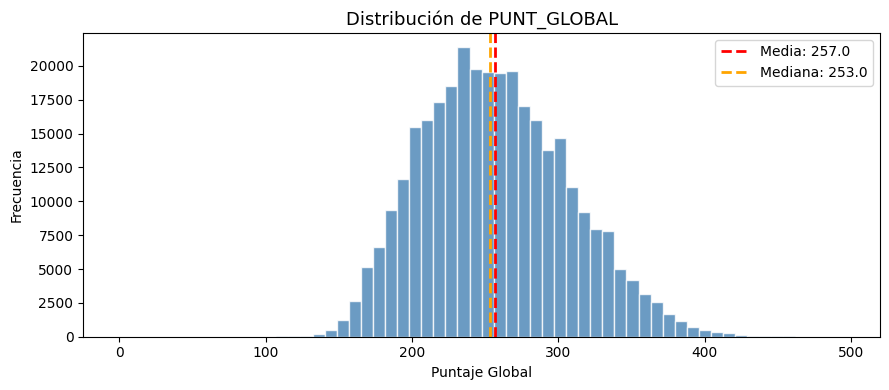

In [7]:

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df_model[TARGET], bins=60, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(df_model[TARGET].mean(), color='red', linestyle='--',
           linewidth=2, label=f'Media: {df_model[TARGET].mean():.1f}')
ax.axvline(df_model[TARGET].median(), color='orange', linestyle='--',
           linewidth=2, label=f'Mediana: {df_model[TARGET].median():.1f}')
ax.set_title('Distribución de PUNT_GLOBAL', fontsize=13)
ax.set_xlabel('Puntaje Global')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.savefig('distribucion_target.png', dpi=150, bbox_inches='tight')
plt.show()